In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import xgboost as xgb

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load fingerprints and labels
X = np.load("data/egfr_fingerprints.npy")
df = pd.read_csv("data/egfr_features_and_labels.csv")
y = df['label'].values

print("Fingerprints shape:", X.shape)
print("Labels shape:", y.shape)
print("Class distribution:", np.bincount(y))

Fingerprints shape: (12424, 2048)
Labels shape: (12424,)
Class distribution: [4139 8285]


In [3]:
# Stratified 80/20 split to preserve the active/inactive ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set:", X_train.shape, "| Test set:", X_test.shape)
print("Train class distribution:", np.bincount(y_train))
print("Test class distribution:", np.bincount(y_test))

# Random Forest baseline
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',  # handles the moderate 64.5/35.5 class imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Evaluate on the held-out test set
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)
print(f"\nRandom Forest ROC-AUC: {rf_auc:.3f}")
print(classification_report(y_test, rf.predict(X_test), target_names=['Inactive', 'Active']))

Train set: (9939, 2048) | Test set: (2485, 2048)
Train class distribution: [3311 6628]
Test class distribution: [ 828 1657]

Random Forest ROC-AUC: 0.943
              precision    recall  f1-score   support

    Inactive       0.82      0.86      0.84       828
      Active       0.93      0.91      0.92      1657

    accuracy                           0.89      2485
   macro avg       0.88      0.88      0.88      2485
weighted avg       0.89      0.89      0.89      2485



In [4]:
# XGBoost on the same train/test split for a fair comparison
scale_pos_weight = np.bincount(y_train)[0] / np.bincount(y_train)[1]

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Evaluate on the held-out test set
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_probs)
print(f"XGBoost ROC-AUC: {xgb_auc:.3f}")
print(classification_report(y_test, xgb_model.predict(X_test), target_names=['Inactive', 'Active']))

XGBoost ROC-AUC: 0.934
              precision    recall  f1-score   support

    Inactive       0.79      0.85      0.82       828
      Active       0.92      0.88      0.90      1657

    accuracy                           0.87      2485
   macro avg       0.85      0.87      0.86      2485
weighted avg       0.88      0.87      0.87      2485



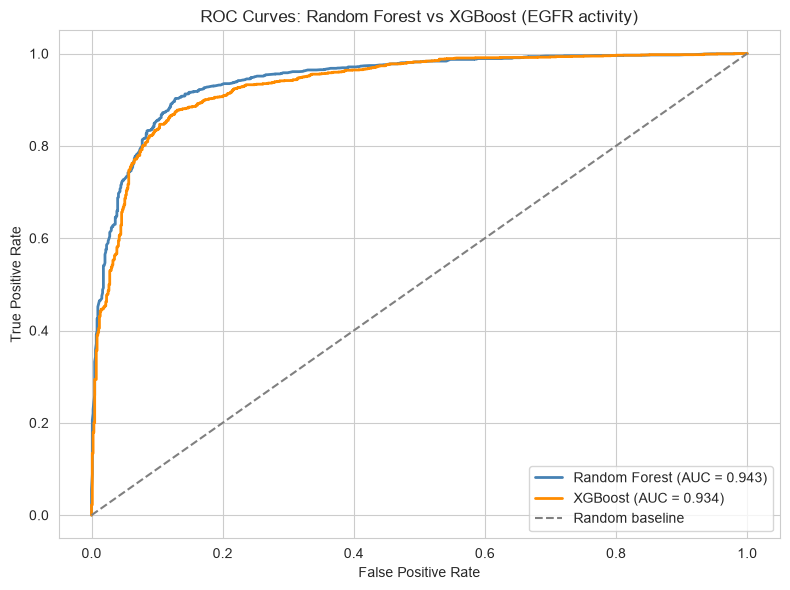

In [5]:
# ROC curves for both models
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, color='steelblue', lw=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(xgb_fpr, xgb_tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {xgb_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Random Forest vs XGBoost (EGFR activity)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('results/plots/roc_rf_vs_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Benchmark: Random Forest vs XGBoost

Both models were trained on 2048-bit Morgan fingerprints with a stratified 80/20 split (9,939 training molecules, 2,485 test molecules) and class weighting for the 66.7% / 33.3% active/inactive imbalance.

| Model | ROC-AUC | PR-AUC | Active recall | Inactive recall |
|-------|---------|--------|---------------|-----------------|
| Random Forest (500 trees) | 0.943 | 0.969 | 0.91 | 0.86 |
| XGBoost (500 trees) | 0.934 | 0.962 | 0.88 | 0.85 |

The random baseline for PR-AUC is the active fraction of the test set (0.667). The two models perform almost identically. Random Forest scores slightly higher on every metric, but a difference of 0.009 ROC-AUC on a single split and a single seed is suggestive, not conclusive.

In [6]:
from collections import defaultdict
from rdkit.Chem.Scaffolds import MurckoScaffold

# Murcko scaffold
def get_scaffold(smiles):
    return MurckoScaffold.MurckoScaffoldSmiles(smiles=smiles, includeChirality=False)

df['scaffold'] = df['canonical_smiles'].apply(get_scaffold)
print("Unique scaffolds:", df['scaffold'].nunique())

# Group molecule indices by scaffold
scaffold_sets = defaultdict(list)
for idx, scaf in enumerate(df['scaffold']):
    scaffold_sets[scaf].append(idx)

# Fill the training set with the largest scaffold groups first (about 80%),
# the remaining (rarer) scaffolds go to the test set
sorted_sets = sorted(scaffold_sets.values(), key=lambda s: (len(s), s[0]), reverse=True)
train_cutoff = 0.8 * len(df)
train_idx, test_idx = [], []
for s in sorted_sets:
    if len(train_idx) + len(s) <= train_cutoff:
        train_idx += s
    else:
        test_idx += s

X_train_s, X_test_s = X[train_idx], X[test_idx]
y_train_s, y_test_s = y[train_idx], y[test_idx]
print("Scaffold split | Train:", X_train_s.shape, "| Test:", X_test_s.shape)
print("Train class distribution:", np.bincount(y_train_s))
print("Test class distribution:", np.bincount(y_test_s))

# Retrain both models on the scaffold split
rf_s = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42, n_jobs=-1)
rf_s.fit(X_train_s, y_train_s)
rf_s_auc = roc_auc_score(y_test_s, rf_s.predict_proba(X_test_s)[:, 1])

spw = np.bincount(y_train_s)[0] / np.bincount(y_train_s)[1]
xgb_s = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.1,
                          scale_pos_weight=spw, random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_s.fit(X_train_s, y_train_s)
xgb_s_auc = roc_auc_score(y_test_s, xgb_s.predict_proba(X_test_s)[:, 1])

print(f"\nScaffold split | Random Forest AUC: {rf_s_auc:.3f} | XGBoost AUC: {xgb_s_auc:.3f}")

Unique scaffolds: 4555
Scaffold split | Train: (9939, 2048) | Test: (2485, 2048)
Train class distribution: [3142 6797]
Test class distribution: [ 997 1488]

Scaffold split | Random Forest AUC: 0.893 | XGBoost AUC: 0.884


In [7]:
desc_cols = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'NumRotatableBonds']
D = df[desc_cols].values
D_train, D_test = D[train_idx], D[test_idx]

def eval_rf(X_tr, X_te, name):
    m = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42, n_jobs=-1)
    m.fit(X_tr, y_train_s)
    auc = roc_auc_score(y_test_s, m.predict_proba(X_te)[:, 1])
    print(f"{name}: AUC = {auc:.3f}")
    return auc

auc_fp = rf_s_auc  # fingerprints only, already computed
auc_desc = eval_rf(D_train, D_test, "Descriptors only")
auc_both = eval_rf(np.hstack([X_train_s, D_train]), np.hstack([X_test_s, D_test]), "Fingerprints + descriptors")
print(f"Fingerprints only: AUC = {auc_fp:.3f}")

Descriptors only: AUC = 0.764
Fingerprints + descriptors: AUC = 0.895
Fingerprints only: AUC = 0.893


In [8]:
from sklearn.metrics import average_precision_score

def report_pr(name, y_true, probs):
    print(f"{name}: PR-AUC = {average_precision_score(y_true, probs):.3f} "
          f"(random baseline = active fraction {y_true.mean():.3f})")

report_pr("Random split   | Random Forest", y_test, rf_probs)
report_pr("Random split   | XGBoost", y_test, xgb_probs)
report_pr("Scaffold split | Random Forest", y_test_s, rf_s.predict_proba(X_test_s)[:, 1])
report_pr("Scaffold split | XGBoost", y_test_s, xgb_s.predict_proba(X_test_s)[:, 1])

Random split   | Random Forest: PR-AUC = 0.969 (random baseline = active fraction 0.667)
Random split   | XGBoost: PR-AUC = 0.962 (random baseline = active fraction 0.667)
Scaffold split | Random Forest: PR-AUC = 0.929 (random baseline = active fraction 0.599)
Scaffold split | XGBoost: PR-AUC = 0.922 (random baseline = active fraction 0.599)


In [9]:
from sklearn.linear_model import LogisticRegression

def tanimoto_matrix(A, B):
    # cast to float32: the fingerprints are uint8 and a matrix product would overflow
    A = A.astype(np.float32)
    B = B.astype(np.float32)
    inter = A @ B.T
    union = A.sum(axis=1)[:, None] + B.sum(axis=1)[None, :] - inter
    return inter / np.maximum(union, 1)

def nn_scores(X_tr, y_tr, X_te):
    """Score = similarity to the nearest training active minus similarity to the nearest training inactive."""
    S = tanimoto_matrix(X_te, X_tr)
    max_act = S[:, y_tr == 1].max(axis=1)
    max_inact = S[:, y_tr == 0].max(axis=1)
    return max_act - max_inact, np.maximum(max_act, max_inact)

splits = {
    "Random split": (X_train, X_test, y_train, y_test),
    "Scaffold split": (X_train_s, X_test_s, y_train_s, y_test_s),
}

for name, (X_tr, X_te, y_tr, y_te) in splits.items():
    lr = LogisticRegression(max_iter=1000, class_weight='balanced')
    lr.fit(X_tr, y_tr)
    lr_probs = lr.predict_proba(X_te)[:, 1]
    nn_diff, nn_max = nn_scores(X_tr, y_tr, X_te)

    print(name)
    print(f"  Logistic regression:      ROC-AUC {roc_auc_score(y_te, lr_probs):.3f} | PR-AUC {average_precision_score(y_te, lr_probs):.3f}")
    print(f"  Tanimoto nearest-neighbour: ROC-AUC {roc_auc_score(y_te, nn_diff):.3f} | PR-AUC {average_precision_score(y_te, nn_diff):.3f}")
    print(f"  Median max Tanimoto to training set: {np.median(nn_max):.2f}")

Random split
  Logistic regression:      ROC-AUC 0.908 | PR-AUC 0.943
  Tanimoto nearest-neighbour: ROC-AUC 0.920 | PR-AUC 0.950
  Median max Tanimoto to training set: 0.82
Scaffold split
  Logistic regression:      ROC-AUC 0.843 | PR-AUC 0.880
  Tanimoto nearest-neighbour: ROC-AUC 0.874 | PR-AUC 0.898
  Median max Tanimoto to training set: 0.73


## Scaffold Split: Generalization to New Chemical Series

Molecules were grouped by Murcko scaffold (4,555 unique scaffolds) and whole scaffold groups were assigned to either the training set (9,939 molecules) or the test set (2,485 molecules).

| Model | Random split ROC-AUC | Scaffold split ROC-AUC |
|-------|----------------------|------------------------|
| Random Forest | 0.943 | 0.893 |
| XGBoost | 0.934 | 0.884 |

Performance drops by about 0.05 for both models on unseen scaffolds, so the random-split numbers are optimistic. The scaffold-split ROC-AUC is the primary result of this project. The split is less strict than its name suggests: the median Tanimoto similarity between a test molecule and its nearest training molecule is 0.73 (0.82 in the random split), so test molecules still have close analogs in the training set. PR-AUC is not compared across splits because the active fraction of the test set differs (0.667 vs 0.599).

## Simple Baselines

Two baselines without feature engineering were evaluated on the same splits: logistic regression on the fingerprints, and a Tanimoto nearest-neighbour score (similarity to the closest training active minus similarity to the closest training inactive), which involves no model training.

| Model | Random: ROC-AUC | Random: PR-AUC | Scaffold: ROC-AUC | Scaffold: PR-AUC |
|-------|-----------------|----------------|-------------------|------------------|
| Logistic regression | 0.908 | 0.943 | 0.843 | 0.880 |
| Tanimoto nearest-neighbour | 0.920 | 0.950 | 0.874 | 0.898 |
| XGBoost | 0.934 | 0.962 | 0.884 | 0.922 |
| Random Forest | 0.943 | 0.969 | 0.893 | 0.929 |

PR-AUC random baselines: 0.667 on the random split, 0.599 on the scaffold split.

The similarity rule reaches 0.874 on the scaffold split, only 0.019 below Random Forest. Most of the predictive signal therefore comes from similarity to known EGFR compounds, and the machine learning models add a modest improvement on top of it.

## Feature Comparison: Fingerprints vs Descriptors

Random Forest models on the scaffold split with three feature sets:

| Features | ROC-AUC |
|----------|---------|
| 6 Lipinski-related descriptors | 0.764 |
| Morgan fingerprints (2048 bits) | 0.893 |
| Fingerprints + descriptors | 0.895 |

Descriptors alone carry some signal but are far less informative than fingerprints. Adding them to the fingerprints changes ROC-AUC by 0.002, within expected variation, so fingerprints alone are used in the rest of the pipeline.